# Data Scientist Professional Practical Exam Submission

**Use this template to write up your summary for submission. Code in Python or R needs to be included.**


## 📝 Task List

Your written report should include both code, output and written text summaries of the following:
- Data Validation:   
  - Describe validation and cleaning steps for every column in the data
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Model Development
  - Include your reasons for selecting the models you use as well as a statement of the problem type
  - Code to fit the baseline and comparison models
- Model Evaluation
  - Describe the performance of the two models based on an appropriate metric
- Business Metrics
  - Define a way to compare your model performance to the business
  - Describe how your models perform using this approach
- Final summary including recommendations that the business should undertake

*Start writing report here..*

In [ ]:
# Start coding here...

The current method of selecting recipes to be displayed on the web homepage is based on personal preference and has led to undesired results.
We have been asked with helping select popular recipes to display on the homepage in order to increase website traffic and subscriptions. The business goals are the following:

- Predict which recipes will be popular (High traffic) 80% of the time
- Minimize the chance of showing unpopular recipes (Low traffic) on the homepage
  
To address this, we developed two binary classification models, using as a baseline model a Logistic Regression model, and as a comparison model a Random Forest Classifier model. We will predict whether a recipe will lead to high or low traffic.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**1. Data Validation & Data Cleaning**

In [ ]:
df = pd.read_csv('recipe_site_traffic_2212.csv')
print(df.shape)
df.head(10)

(947, 8)


,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,High
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,NaN
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,NaN
5,6,691.15,3.46,1.65,53.93,One Dish Meal,2,High
6,7,183.94,47.95,9.75,46.71,Chicken Breast,4,NaN
7,8,299.14,3.17,0.40,32.40,Lunch/Snacks,4,NaN
8,9,538.52,3.78,3.37,3.79,Pork,6,High
9,10,248.28,48.54,3.99,113.85,Chicken,2,NaN


This dataset contains 947 rows and 8 columns.

In [ ]:
df['recipe'].nunique()

947

In [ ]:
#Number of duplicated rows
df.duplicated().sum()

0

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        947 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      947 non-null    object 
 6   servings      947 non-null    object 
 7   high_traffic  574 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 59.3+ KB


In [ ]:
df.describe()

,recipe,calories,carbohydrate,sugar,protein
count,947.000000,895.000000,895.000000,895.000000,895.000000
mean,474.000000,435.939196,35.069676,9.046547,24.149296
std,273.519652,453.020997,43.949032,14.679176,36.369739
min,1.000000,0.140000,0.030000,0.010000,0.000000
25%,237.500000,110.430000,8.375000,1.690000,3.195000
50%,474.000000,288.550000,21.480000,4.550000,10.800000
75%,710.500000,597.650000,44.965000,9.800000,30.200000
max,947.000000,3633.160000,530.420000,148.750000,363.360000


In [ ]:
df.isna().sum()

recipe            0
calories         52
carbohydrate     52
sugar            52
protein          52
category          0
servings          0
high_traffic    373
dtype: int64

The features calories, carbohydrate, sugar and protein have all the same number of missing values. We are now going to check if the rows where this features have missing values correspond to the same set of rows.

In [ ]:
nan_cal = df['calories'].isna()
nan_carb = df['carbohydrate'].isna()
nan_sugar = df['sugar'].isna()
nan_protein = df['protein'].isna()

# Check if all these masks are equal
same_rows = (nan_cal.equals(nan_carb) and
            nan_cal.equals(nan_sugar) and
            nan_cal.equals(nan_protein))

print(same_rows)

True


In [ ]:
print((52/947)*100)

5.4910242872228086


As we can see, 52 rows have missing values across the nutritional info columns, and we have confirmed that these rows correspond to the same set of rows. These rows barely represent around 5% of the total data. Also, imputing the mean of these columns to these missing values wouldn't be the best thing to do as it would change the nutritional information of the recipes, leading to unconsistent data. Therefore, we concluded that the best approach is to drop these 52 rows.

In [ ]:
df = df.dropna(subset=['calories','carbohydrate','sugar','protein'], how='all')
df.shape

(895, 8)

In [ ]:
df.isna().sum()

recipe            0
calories          0
carbohydrate      0
sugar             0
protein           0
category          0
servings          0
high_traffic    360
dtype: int64

In [ ]:
df['high_traffic'].value_counts(dropna=False)

High    535
NaN     360
Name: high_traffic, dtype: int64

The target column high_traffic has 535 rows labeled as 'High', and the rest of the rows have missing values. The goal of this project is to predict which recipes will be popular (High traffic) and non popular (Low Traffic). Only one type of recipes are labeled, so this suggests that the rest of the rows, that have missing values, should correspond to Low Traffic recipes. We have decided to change the missing values to 'Low'.

In [ ]:
df['high_traffic'] = df['high_traffic'].fillna("Low")
df['high_traffic'].value_counts()

High    535
Low     360
Name: high_traffic, dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 895 entries, 1 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        895 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      895 non-null    object 
 6   servings      895 non-null    object 
 7   high_traffic  895 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 62.9+ KB


In [ ]:
df['category'].value_counts()

Breakfast         106
Chicken Breast     94
Beverages          92
Potato             83
Lunch/Snacks       82
Vegetable          78
Dessert            77
Meat               74
Pork               73
Chicken            69
One Dish Meal      67
Name: category, dtype: int64

According to the data information in the project brief, the range of valid values in the 'category' column is 10, and these 10 groupings are the following ones:
Lunch/Snacks, Beverages, Potato, Vegetable, Meat, Chicken, Pork, Dessert, Breakfast, One Dish Meal
As we can see, there are 94 values of a 'Chicken Breast' category. Since this category is not a valid value, we have decided to change it to the 'Chicken' category.

In [ ]:
df['category'] = df['category'].replace({
    'Chicken Breast': 'Chicken'
})

df['category'].value_counts()

Chicken          163
Breakfast        106
Beverages         92
Potato            83
Lunch/Snacks      82
Vegetable         78
Dessert           77
Meat              74
Pork              73
One Dish Meal     67
Name: category, dtype: int64

Also, the 'category' column is stored as an object (string) and, as it only has 10 possible groups, we are going to change it to a 'category' datatype.

In [ ]:
df['category'] = df['category'].astype('category')

In [ ]:
df['servings'].value_counts()

4               365
6               184
2               174
1               169
4 as a snack      2
6 as a snack      1
Name: servings, dtype: int64

The 'servings' column is stored as an object, when it should be stored as a numeric column. As we can see, there are three rows recorded with values which are not integers numbers. Two of those three rows are recorded as '4 as a snack', and one row is recorded as '6 as a snack'. To ensure consistency across the column, we have decided to change this three entries to 4 and 6, respectively.
Aditionally, we have changed the type of this column to numerical (int) datatype.

In [ ]:
df['servings'] = df['servings'].replace({
    '4 as a snack': '4',
    '6 as a snack': '6'
})

df['servings'] = df['servings'].astype('int')
df['servings'].value_counts()

4    367
6    185
2    174
1    169
Name: servings, dtype: int64

Finally, the 'high_traffic' target variable is stored as an object, and we are going to change it to a binary numerical variable to ensure that it can be used and handled by machine learning algorithms, as these algorithms can only handle numerical data. We are going to change the entries recorded as 'High' to the value 1, which will correspond to the posistive class instances, and the entries recorded as 'Low' will be changed to the value 0.

In [ ]:
df['high_traffic'] = df['high_traffic'].replace({
    'High': '1',
    'Low': '0'
})
df['high_traffic'] = df['high_traffic'].astype('int')
df['high_traffic'].value_counts()

1    535
0    360
Name: high_traffic, dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 895 entries, 1 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   recipe        895 non-null    int64   
 1   calories      895 non-null    float64 
 2   carbohydrate  895 non-null    float64 
 3   sugar         895 non-null    float64 
 4   protein       895 non-null    float64 
 5   category      895 non-null    category
 6   servings      895 non-null    int64   
 7   high_traffic  895 non-null    int64   
dtypes: category(1), float64(4), int64(3)
memory usage: 57.2 KB


I have validated all variables and I have made several changes after validation. Some columns were as described in the data dictionary but other columns had some problems and inconsistencies. I have removed 52 rows with missing values in the 'calories', 'carbohydrate', 'sugar' and 'protein' columns".

- recipe: 947 unique values without missing values. No cleaning is needed.
- calories: 895 non-null numeric values. I deleted 52 rows with missing values.
- carbohydrate: 895 non-null numeric values. I deleted 52 rows with missing values.
- sugar: 895 non-null numeric values. I deleted 52 rows with null values.
- protein: 895 non-null numeric values. I deleted 52 rows with null values.
- category: 11 unique values without missing values. The extra value was 'Chicken Breast'. Since this value was not in the valid range of the 10 groupings stated in the data dictionary, I changed these 94 entries recorded as 'Chicken Breast' to the 'Chicken' value. I also had to change the column to 'category' datatype.
- servings: 6 unique values without missing values. There were two extra values: '4 as a snack' and '6 as a snack'. I changed them to '4' and '6', respectively, and changed the column to numerical (int) datatype.
- high_traffic: 535 non-missing values stored as ("High"). The rest of the values, 360, were missing, and i replaced these to the value "Low". I also change the column datatype to numeric (int).

In [ ]:
num_cols = ['calories', 'carbohydrate', 'sugar', 'protein']

outliers_details = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outliers_details[col] = len(outliers)

outliers_details

{'calories': 47, 'carbohydrate': 58, 'sugar': 79, 'protein': 77}

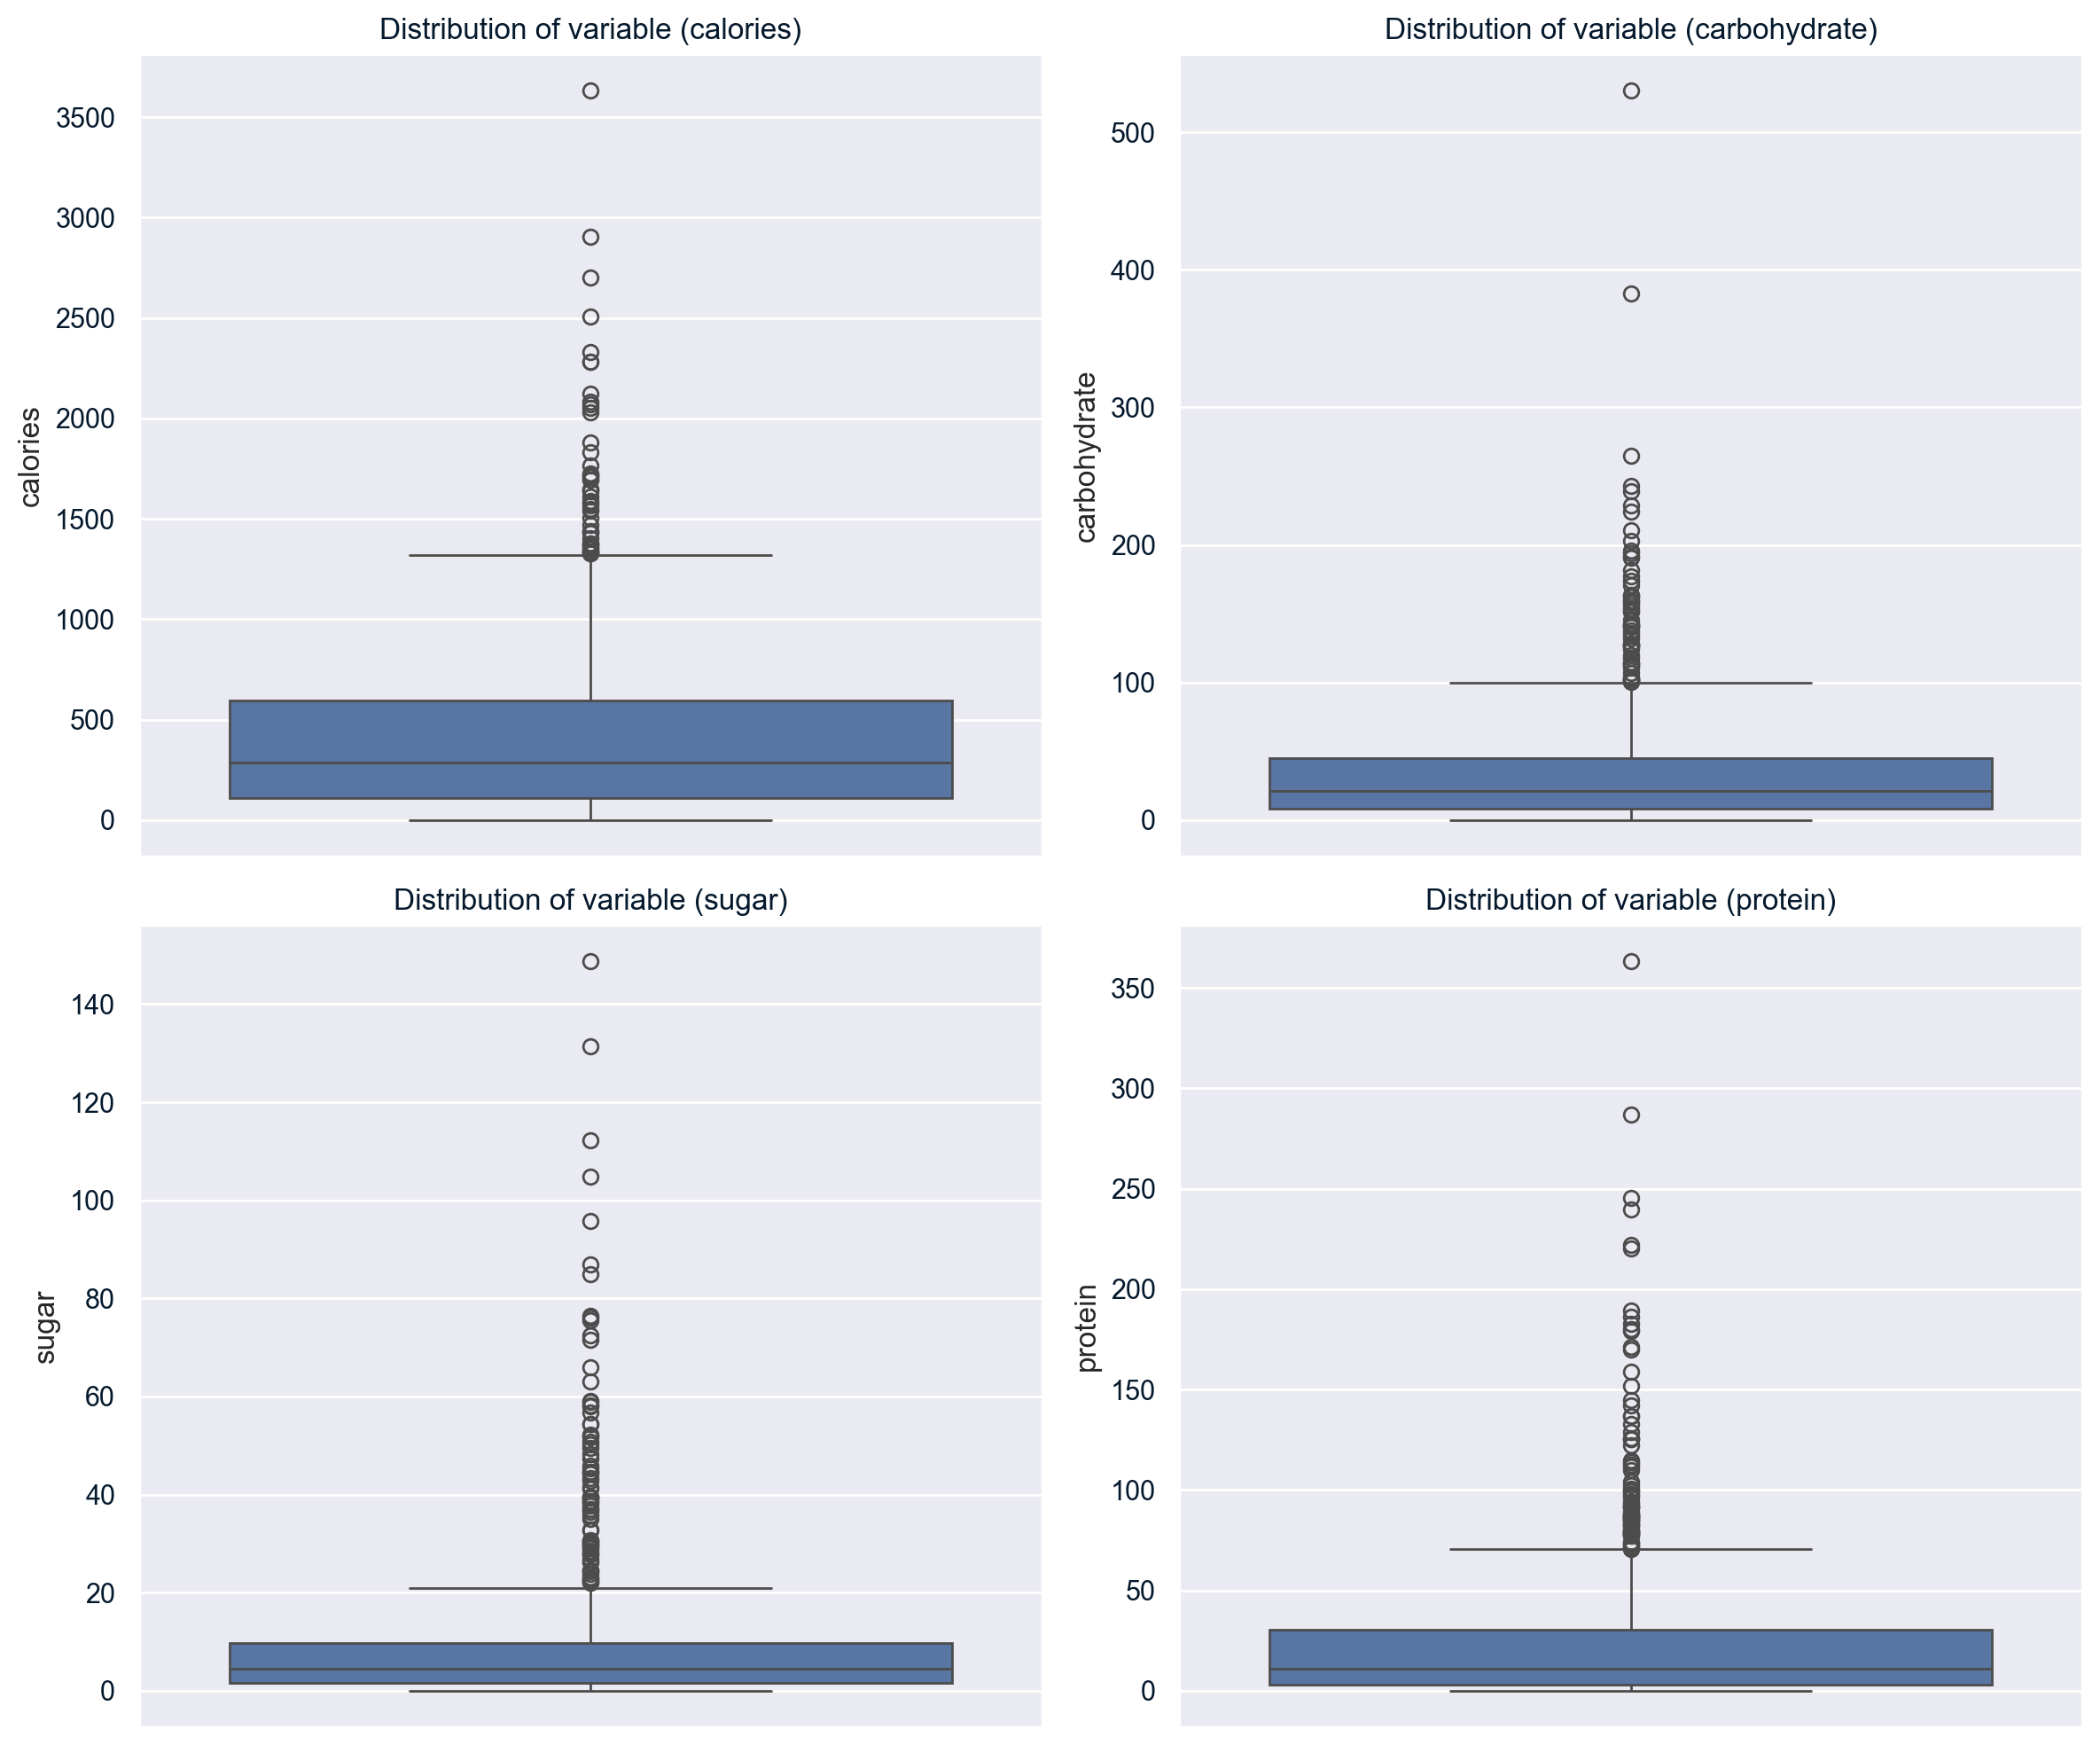

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=ax
    )
    ax.set_title(f"Distribution of variable ({col})")

plt.tight_layout()
plt.show()

As we can see, there are some outliers in the dataset. This represent roughly between 5% to 8% of the total dataset.
We have decided to not delete these values, and preserve the distributions of the data, as these values would probably correspond to some recipes which are sweet desserts with more sugar and calories, and some others rich in proteins or carbohydrates.

**2. Exploratory Data Analysis**

**Target Variable - high_traffic**

In [ ]:
df['high_traffic'].value_counts(normalize=True)

1    0.597765
0    0.402235
Name: high_traffic, dtype: float64

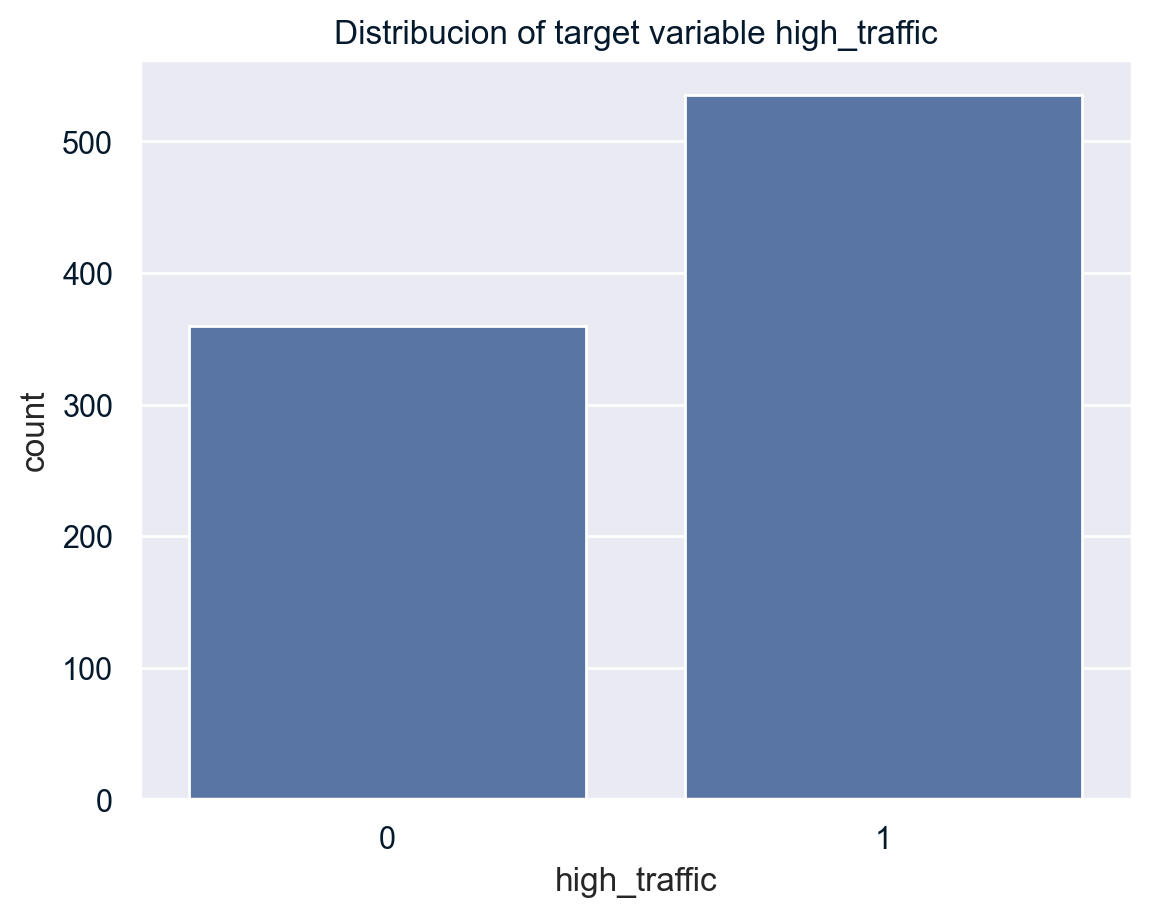

In [ ]:
sns.countplot(x='high_traffic', data=df).set(title='Distribucion of target variable high_traffic')
sns.set(style="darkgrid")

As we can see in the graphic above, the target variable has a moderate class imbalance, with high-traffic recipes being more common. The instances with the positive class represent around 60% of the total instances, and the instances with the negative class represent around 40% of the total.

**Numeric variables - calories, carbohydrate, sugar and protein**

[Text(0.5, 1.0, 'Linear Correlation between Numeric Variables')]

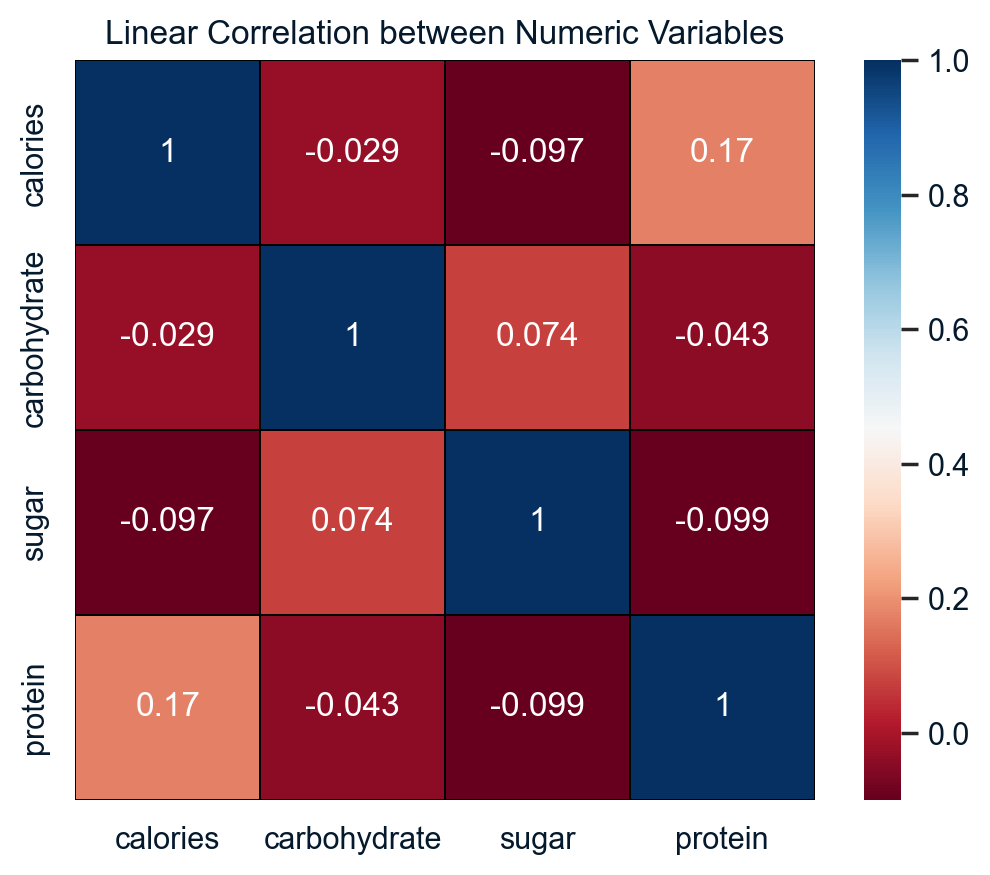

In [ ]:
sns.heatmap(df[num_cols].corr(), annot=True, linewidth=0.01, square=True, cmap="RdBu", linecolor="black").set(title='Linear Correlation between Numeric Variables')

As we can see in the heatmap of correlations above, there is almost none linear correlation between the numerical nutritional information variables. There is a small linear correlation between the protein an calories variables.

**Distributions of calories, carbohydrate, sugar and protein**

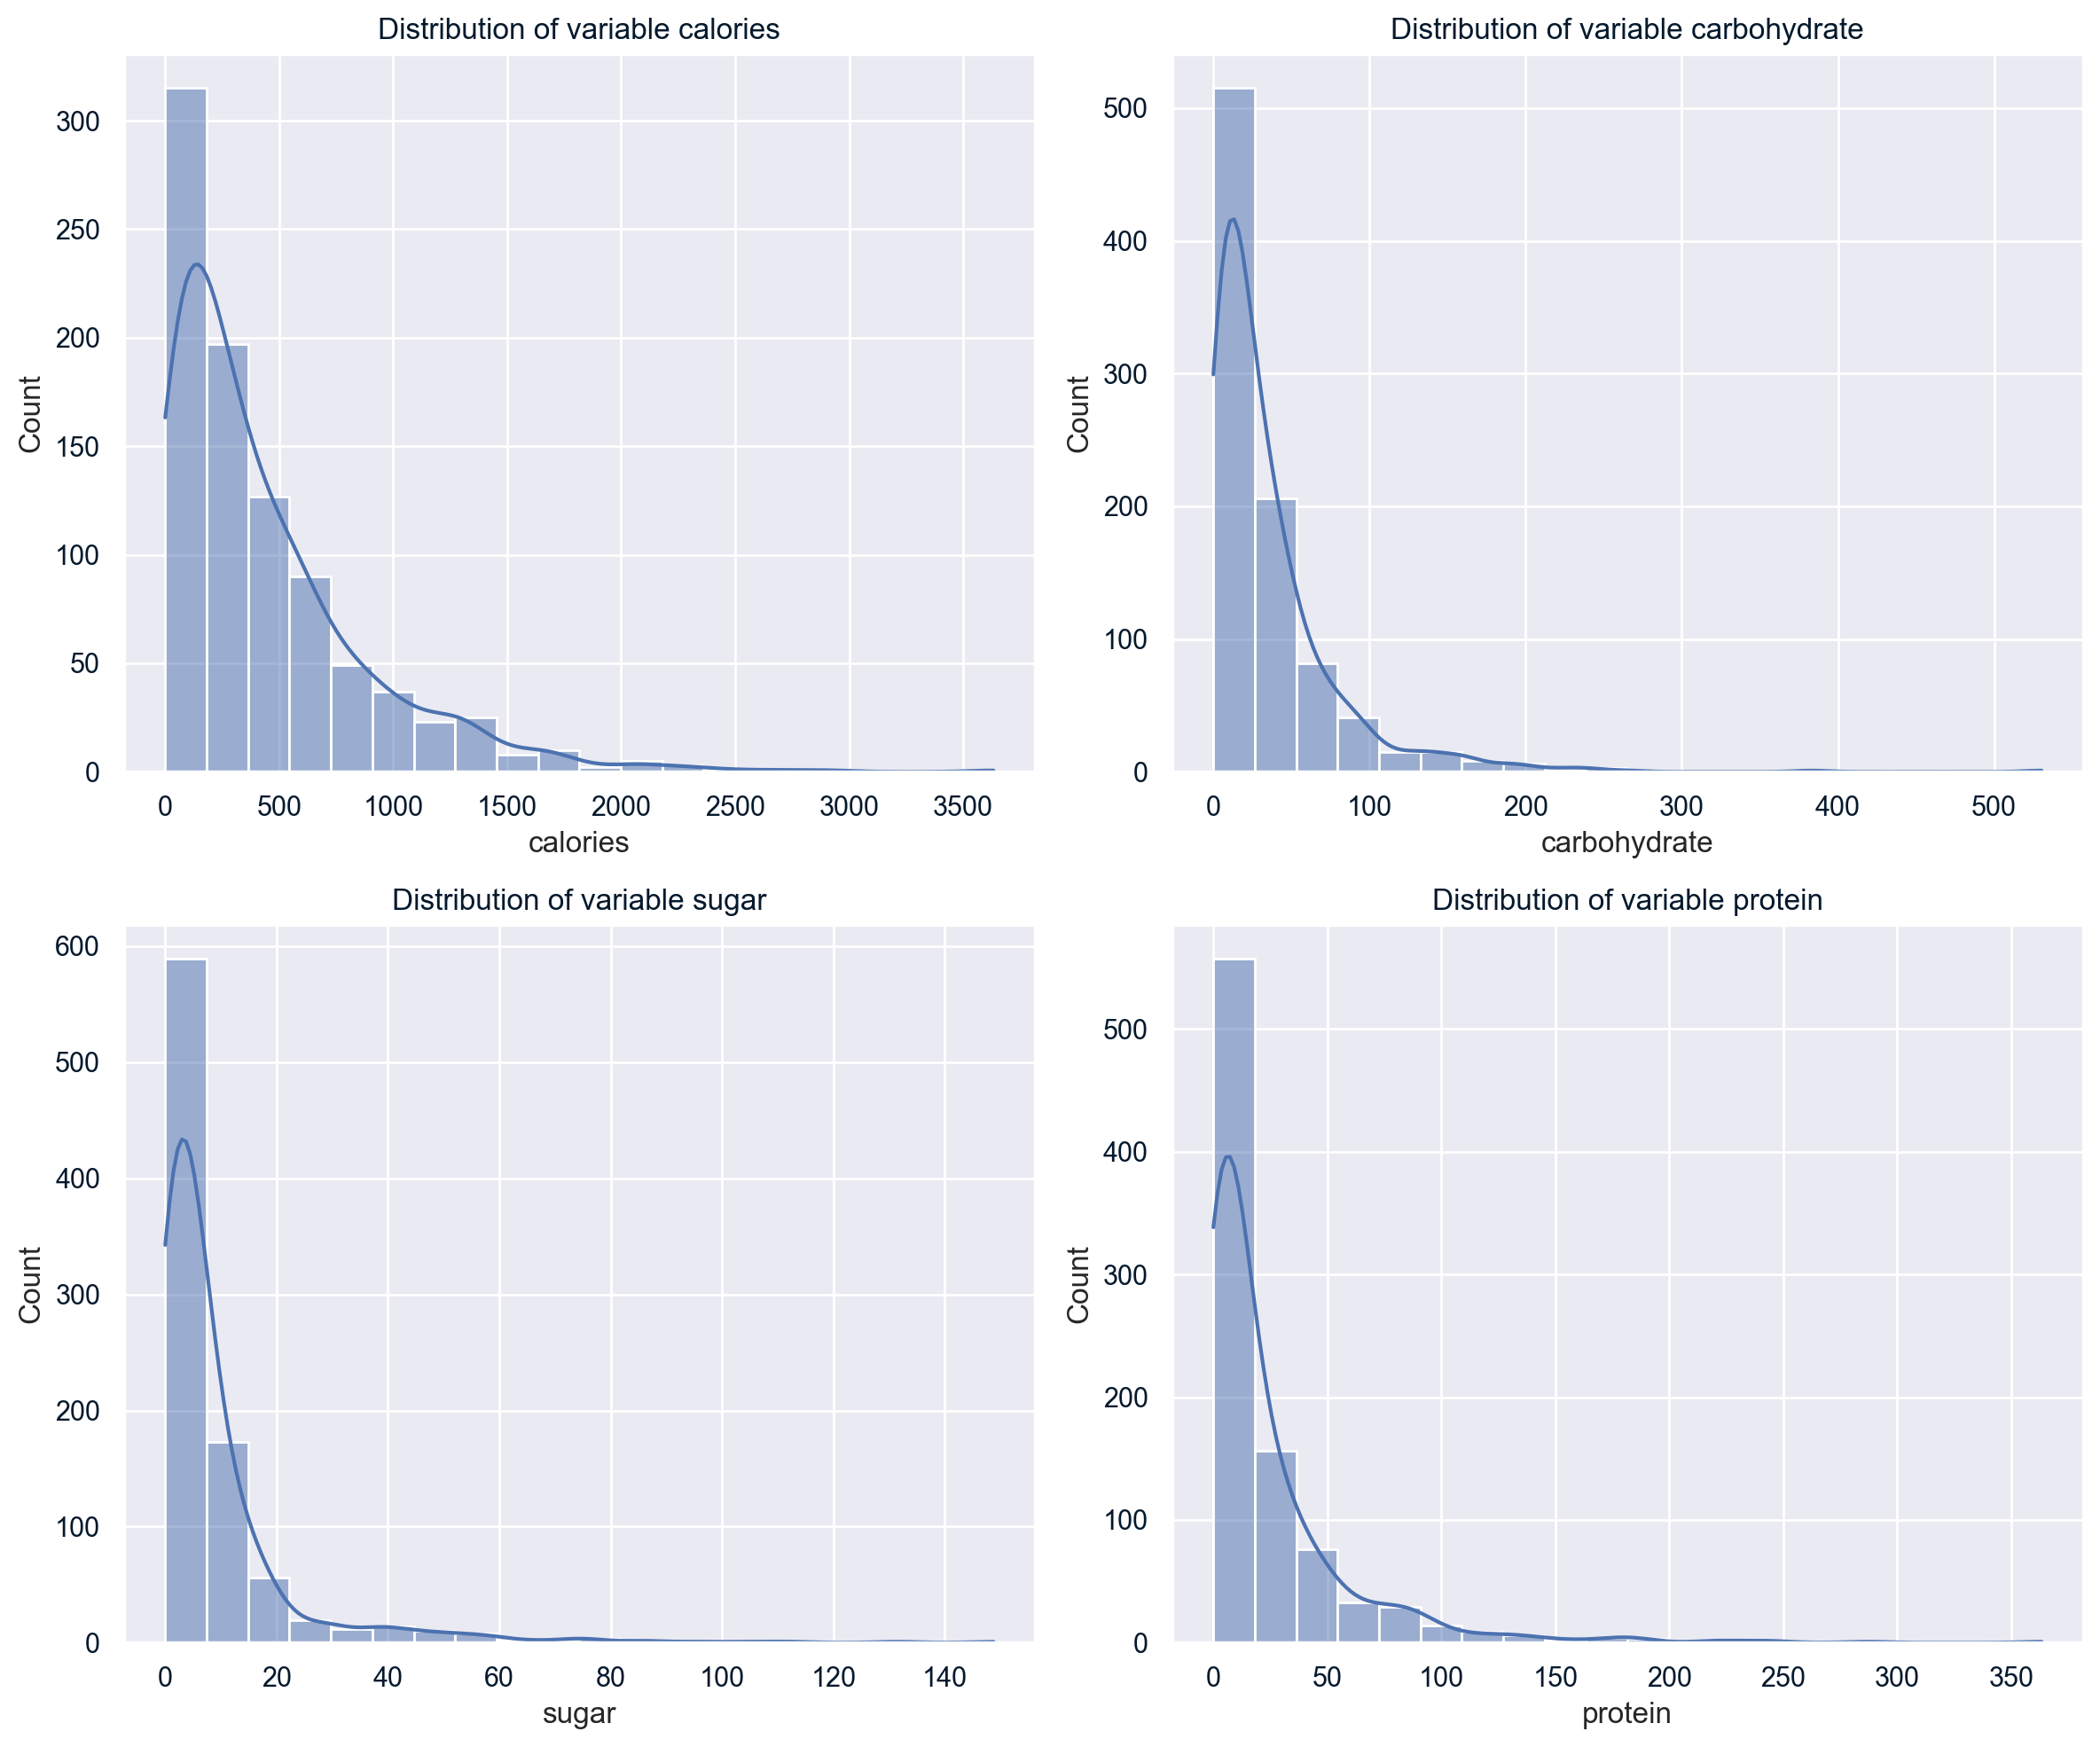

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, var in zip(axes, num_cols):
    sns.histplot(
        data=df,
        x=var,
        kde=True,
        bins=20,
        ax=ax
    )
    ax.set_title(f"Distribution of variable {var}")

plt.tight_layout()
plt.show()

The histogram analysis shows that all the numerical variables (nutritional variables - calories, carbohydrate, sugar, protein) have right-skewed distributions. We will Transform this variables with PowerTransformer() to stabilize variance and reduce skewness, so that these distribution are more normalized.

**Relationship Between Numerical features (calories, carbohydrate, sugar, protein) and high_traffic**

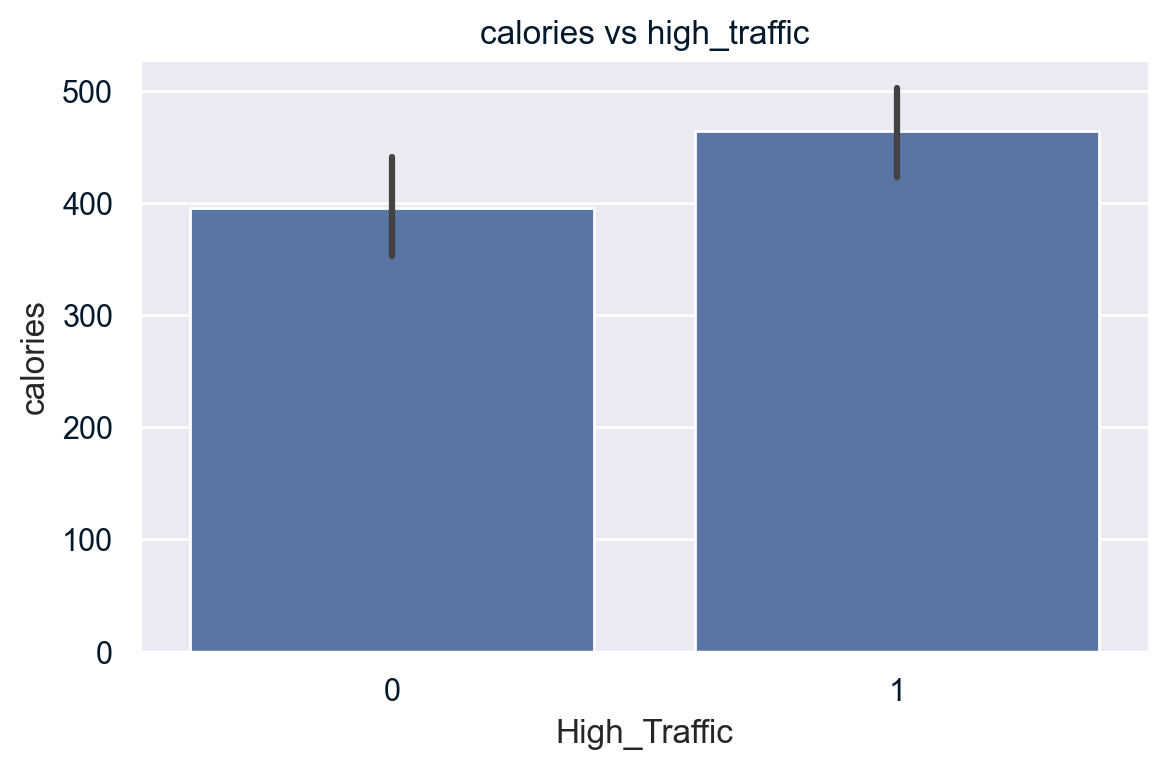

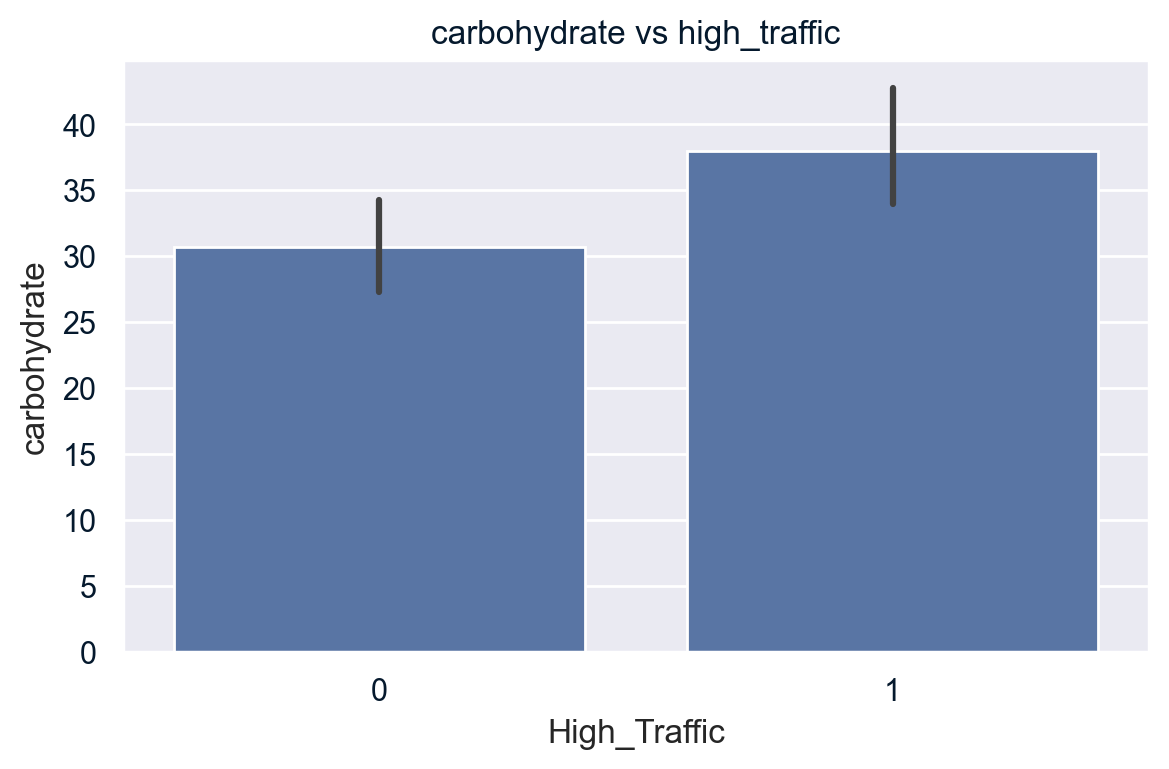

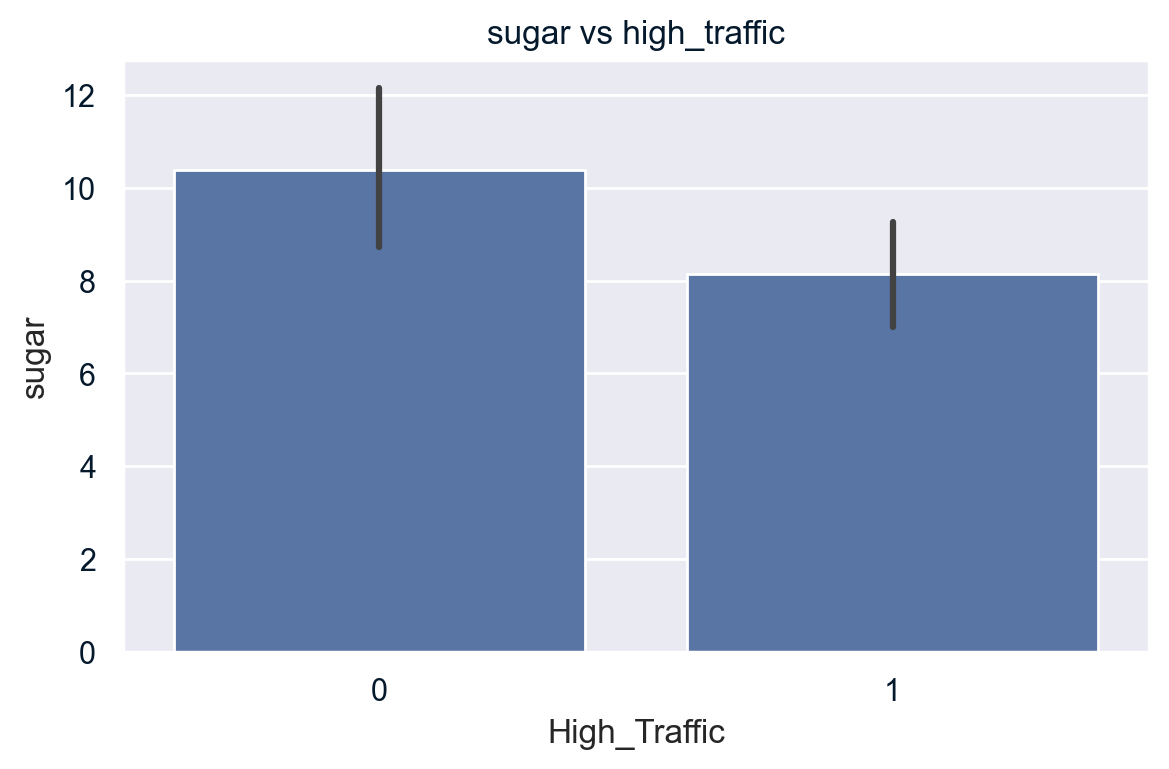

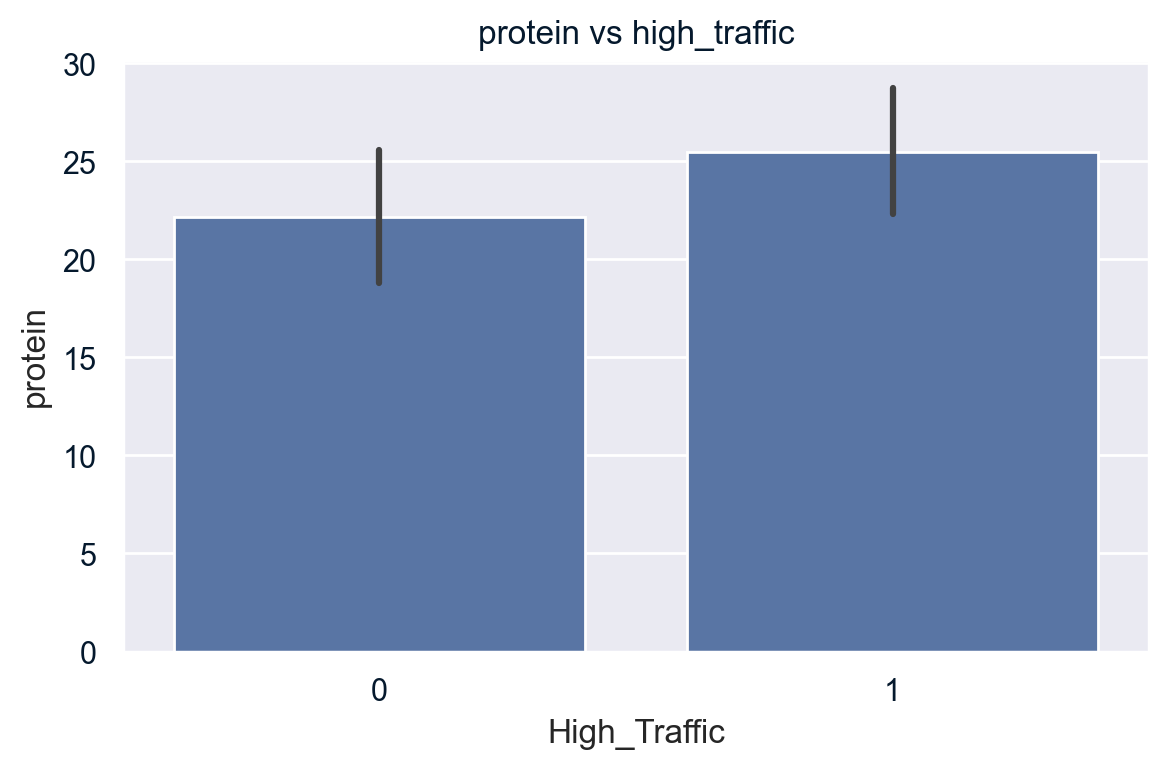

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    ax = sns.barplot(
        data=df,
        x="high_traffic",
        y=col
    )
    ax.set_title(f"{col} vs high_traffic")
    ax.set_xlabel("High_Traffic")
    ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()

According to the bar plots shown above, we can observe that the recipes labeled as 'high_traffic' (positive class) have, on average, higher levels of calories, carbohydrate and protein compared to the recipes labeled as 'low_traffic' (negative class). In contrast, the recipes labeled as 'low_traffic' (negative class) have, on average, higher levels of sugar. This may indicate that people prefer healthier food recipes, with less sugar.

**Categorical Variables - servings, category. Relationship between Categorical variables and target variable - high_traffic**

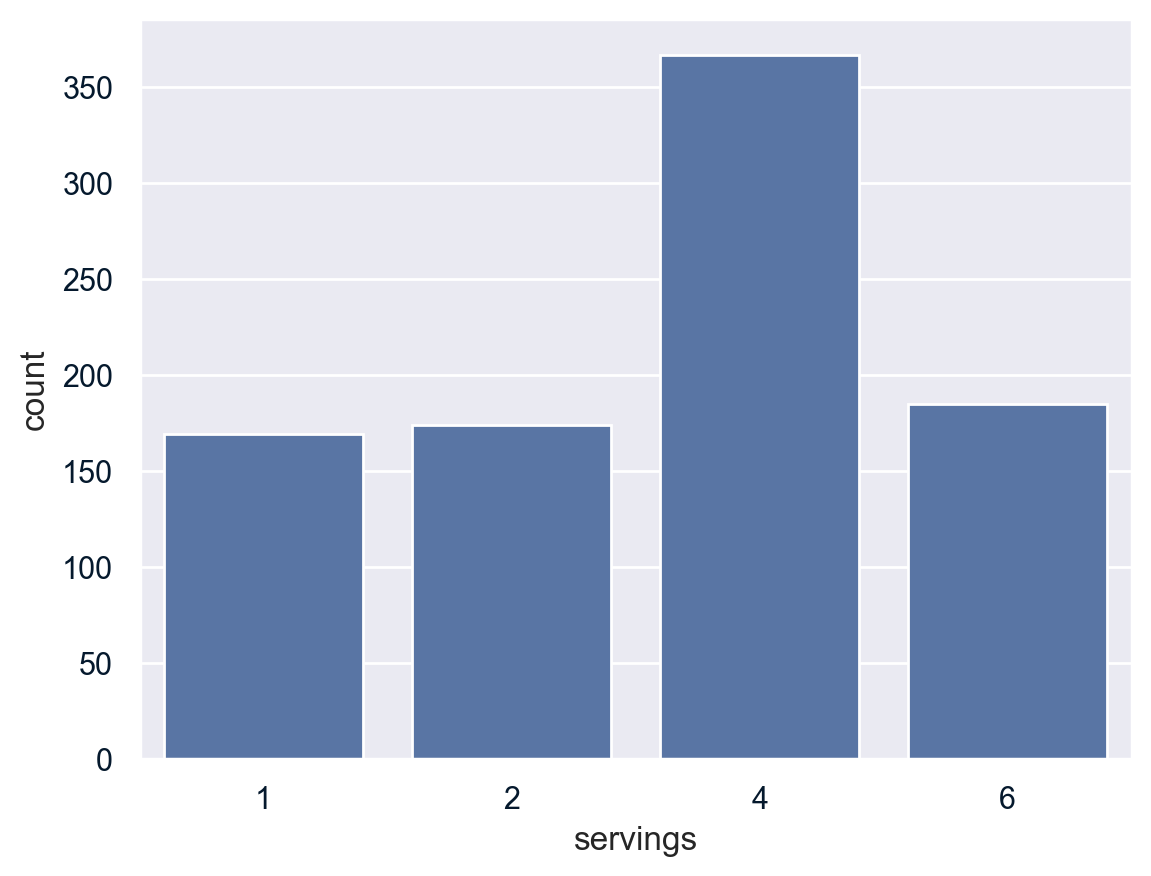

In [ ]:
sns.countplot(df, x="servings")
plt.show()

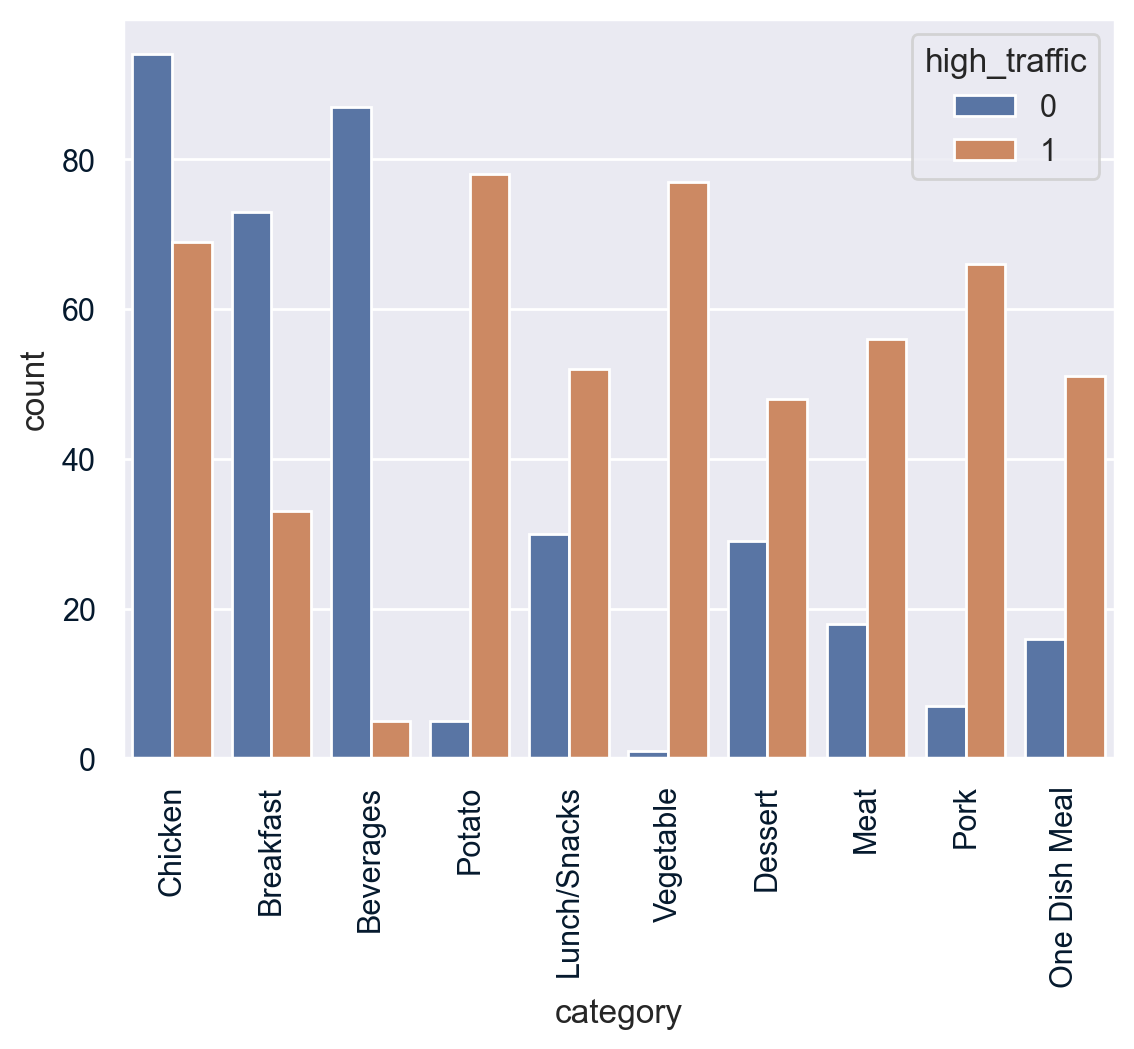

In [ ]:
sns.countplot(df, x="category", hue="high_traffic", order=df['category'].value_counts().index)
plt.xticks(rotation=90)
plt.show()

The category of the variable 'serving' which is more common in the dataset is 4. This means that the most common recipes are those for four servings.
In addition, the majority of low-traffic recipes are the those from the categories of Chicken, Beverages, and Breakfast, whereas the recipes which are more popular are mainly from the Vegetable, Potato and Chicken categories.
Beverages and Breakfast recipes tend to be less popular, and Potato, Vegetable and Pork recipes tend to be much more popular. Chicken recipes are the most common recipes, and among these chicken recipes, there are both popular recipes and unpopular recipes.

**3. Data Preprocessing**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

In [ ]:
df.columns

Index(['recipe', 'calories', 'carbohydrate', 'sugar', 'protein', 'category',
       'servings', 'high_traffic'],
      dtype='object')

To enable modelling, we chose calories, carbohydrate, sugar, protein, category and servings as features, high_traffic as the target variable. I also have made the following changes:

- Split the data into a training set and a test set
- Normalize the numeric features (calories, carbohydrate, sugar, protein)  applying the Yeo-Johnson method
- Convert the categorical variables into numeric features with OneHotEncoder
- Scale the numerical features with StandardScaler


**Data Splitting**

In [ ]:
X = df.drop(columns=['recipe', 'high_traffic'])
y = df['high_traffic']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
X_test.shape

(716, 6)


(179, 6)

**Yeo-Johnson transformation to numeric features (calories, carbohydrate, sugar, protein)**

We are going to transform this variables with PowerTransformer(), using the Yeo-Johnson method, to stabilize their variance and reduce skewness, so that these distribution are more normalized. We are going to use the Yeo-Johnson method instead of the Box-Cox method because the column protein has some values of zero. The Yeo-Johnson technique allow having zeros in the columns to transform, whereas the Box-Cox method requires that all of the values of the columns are positive.

In [ ]:
df.describe()

,recipe,calories,carbohydrate,sugar,protein,servings,high_traffic
count,895.000000,895.000000,895.000000,895.000000,895.000000,895.000000,895.000000
mean,473.652514,435.939196,35.069676,9.046547,24.149296,3.458101,0.597765
std,272.763283,453.020997,43.949032,14.679176,36.369739,1.735979,0.490623
min,2.000000,0.140000,0.030000,0.010000,0.000000,1.000000,0.000000
25%,237.500000,110.430000,8.375000,1.690000,3.195000,2.000000,0.000000
50%,475.000000,288.550000,21.480000,4.550000,10.800000,4.000000,1.000000
75%,708.500000,597.650000,44.965000,9.800000,30.200000,4.000000,1.000000
max,947.000000,3633.160000,530.420000,148.750000,363.360000,6.000000,1.000000


In [ ]:
df[df['protein']==0]['protein']

468    0.0
812    0.0
Name: protein, dtype: float64

In [ ]:
X_train_transformed = X_train.copy()
X_test_transformed = X_test.copy()

transformer = PowerTransformer(method='yeo-johnson', standardize=False)

X_train_yj = transformer.fit_transform(X_train_transformed[num_cols])
X_test_yj = transformer.transform(X_test_transformed[num_cols])

X_train_transformed[num_cols] = X_train_yj
X_test_transformed[num_cols] = X_test_yj

X_train = X_train_transformed
X_test = X_test_transformed

**Scaling numerical features with StandardScaler**

In [ ]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

Applying OneHotEncoding to the categorical variable 'category'. I'm using OneHotEncoder(), and i'm doing this after the train_test_split, instead of using pd.get_dummies() before the split, to avoid data leakage.

In [ ]:
ohe = OneHotEncoder(
    handle_unknown="ignore",
    sparse=False
)

cat_col = "category"

X_train_cat = ohe.fit_transform(X_train[[cat_col]])
X_test_cat = ohe.transform(X_test[[cat_col]])

cat_feature_names = ohe.get_feature_names_out([cat_col])

X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=cat_feature_names,
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=cat_feature_names,
    index=X_test.index
)

X_train_num = X_train.drop(columns=[cat_col])
X_test_num = X_test.drop(columns=[cat_col])

X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

**4. Model Fitting & Model Evaluation**

Predicting food recipes as high-traffic or low-traffic is a binary classification problem in machine learning.
We have selected the Logistic Regression model as the baseline model for its simplicity and interpretability.
And we have opted for the Random Forest Classifier model for the comparison model. Random Forest is an ensemble learning algorithm that combines multiple decision trees, offering higher accuracy and robustness to overfitting compared to a single Decision Tree classifier.

We have used three metrics to evaluate the models the following: Recall, Precision and F1-score.
- Recall, which measures the % of the high-traffic recipes the model manages to identify correctly
- Precision, which measures, among the recipes predicted as high-traffic by the model, the % of which recipes are truly high-traffic
- F1-score is a balance between Precision and Recall. It measures how good is the model at both finding popular (high-traffic) recipes and avoiding bad recommendations (low-traffic recipes)

**Logistic Regression Model**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_pred_prob_lr = lr.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification report:\n", classification_report(y_test, y_pred_lr))

recall_lr = recall_score(y_test, y_pred_lr, pos_label=1)
precision_lr = precision_score(y_test, y_pred_lr, pos_label=1)
f1_lr = f1_score(y_test, y_pred_lr, pos_label=1)

print(f"Recall: {recall_lr:.2f}")
print(f"Precision: {precision_lr:.2f}")
print(f"F1-score: {f1_lr:.2f}")

Confusion Matrix:
 [[58 14]
 [27 80]]
Classification report:
               precision    recall  f1-score   support

           0       0.68      0.81      0.74        72
           1       0.85      0.75      0.80       107

    accuracy                           0.77       179
   macro avg       0.77      0.78      0.77       179
weighted avg       0.78      0.77      0.77       179

Recall: 0.75
Precision: 0.85
F1-score: 0.80


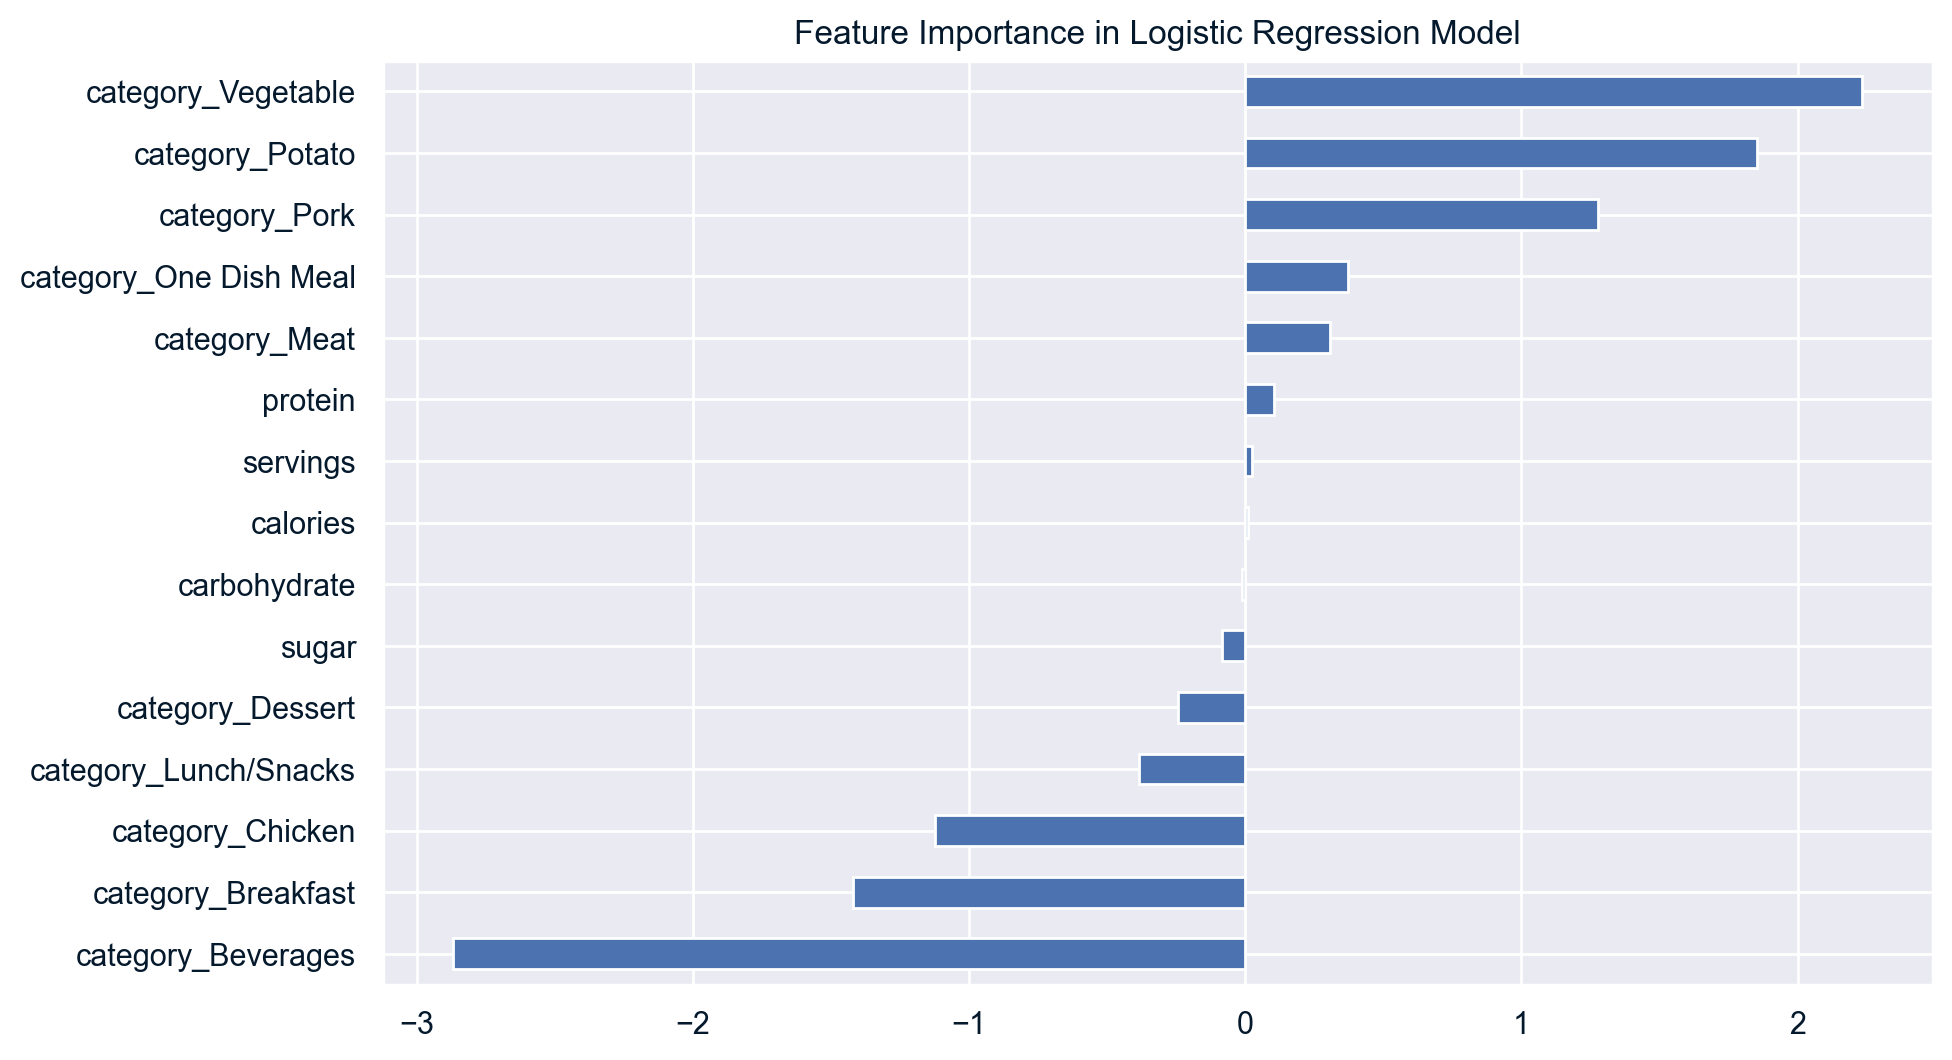

In [ ]:
column_order = X_train.columns
importances_lr = pd.Series(lr.coef_[0],index=column_order).sort_values()
plt.figure(figsize=(10, 6))
importances_lr.plot(kind='barh')
plt.title('Feature Importance in Logistic Regression Model')
plt.show()

The Logistic Regression Model hasn't managed to meet the minimum requirement of predicting the 80% of the total of the high-traffic recipes (positive class). When it comes to the positive class instances, this model has obtained a recall of 0.75, a precision of 0.85 and a F1-score of 0.80, respectivelly. This model is then not appropiate to be deployed in production as it didn't meet the minimum requirements of the company.

It's important to note as well, that the features that had the most predictive importance in this model were the dummies variables corresponding to the categories of the recipes, especially the Beverages, Vegetable, Potato and Pork categories.

**Random Forest Classifier Model**

In [ ]:
rf = RandomForestClassifier(n_estimators=20, max_depth=10, min_samples_split=3, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification report:\n", classification_report(y_test, y_pred_rf))

recall_rf = recall_score(y_test, y_pred_rf, pos_label=1)
precision_rf = precision_score(y_test, y_pred_rf, pos_label=1)
f1_rf = f1_score(y_test, y_pred_rf, pos_label=1)

print(f"Recall: {recall_rf:.2f}")
print(f"Precision: {precision_rf:.2f}")
print(f"F1-score: {f1_rf:.2f}")

Confusion Matrix:
 [[52 20]
 [21 86]]
Classification report:
               precision    recall  f1-score   support

           0       0.71      0.72      0.72        72
           1       0.81      0.80      0.81       107

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179

Recall: 0.80
Precision: 0.81
F1-score: 0.81


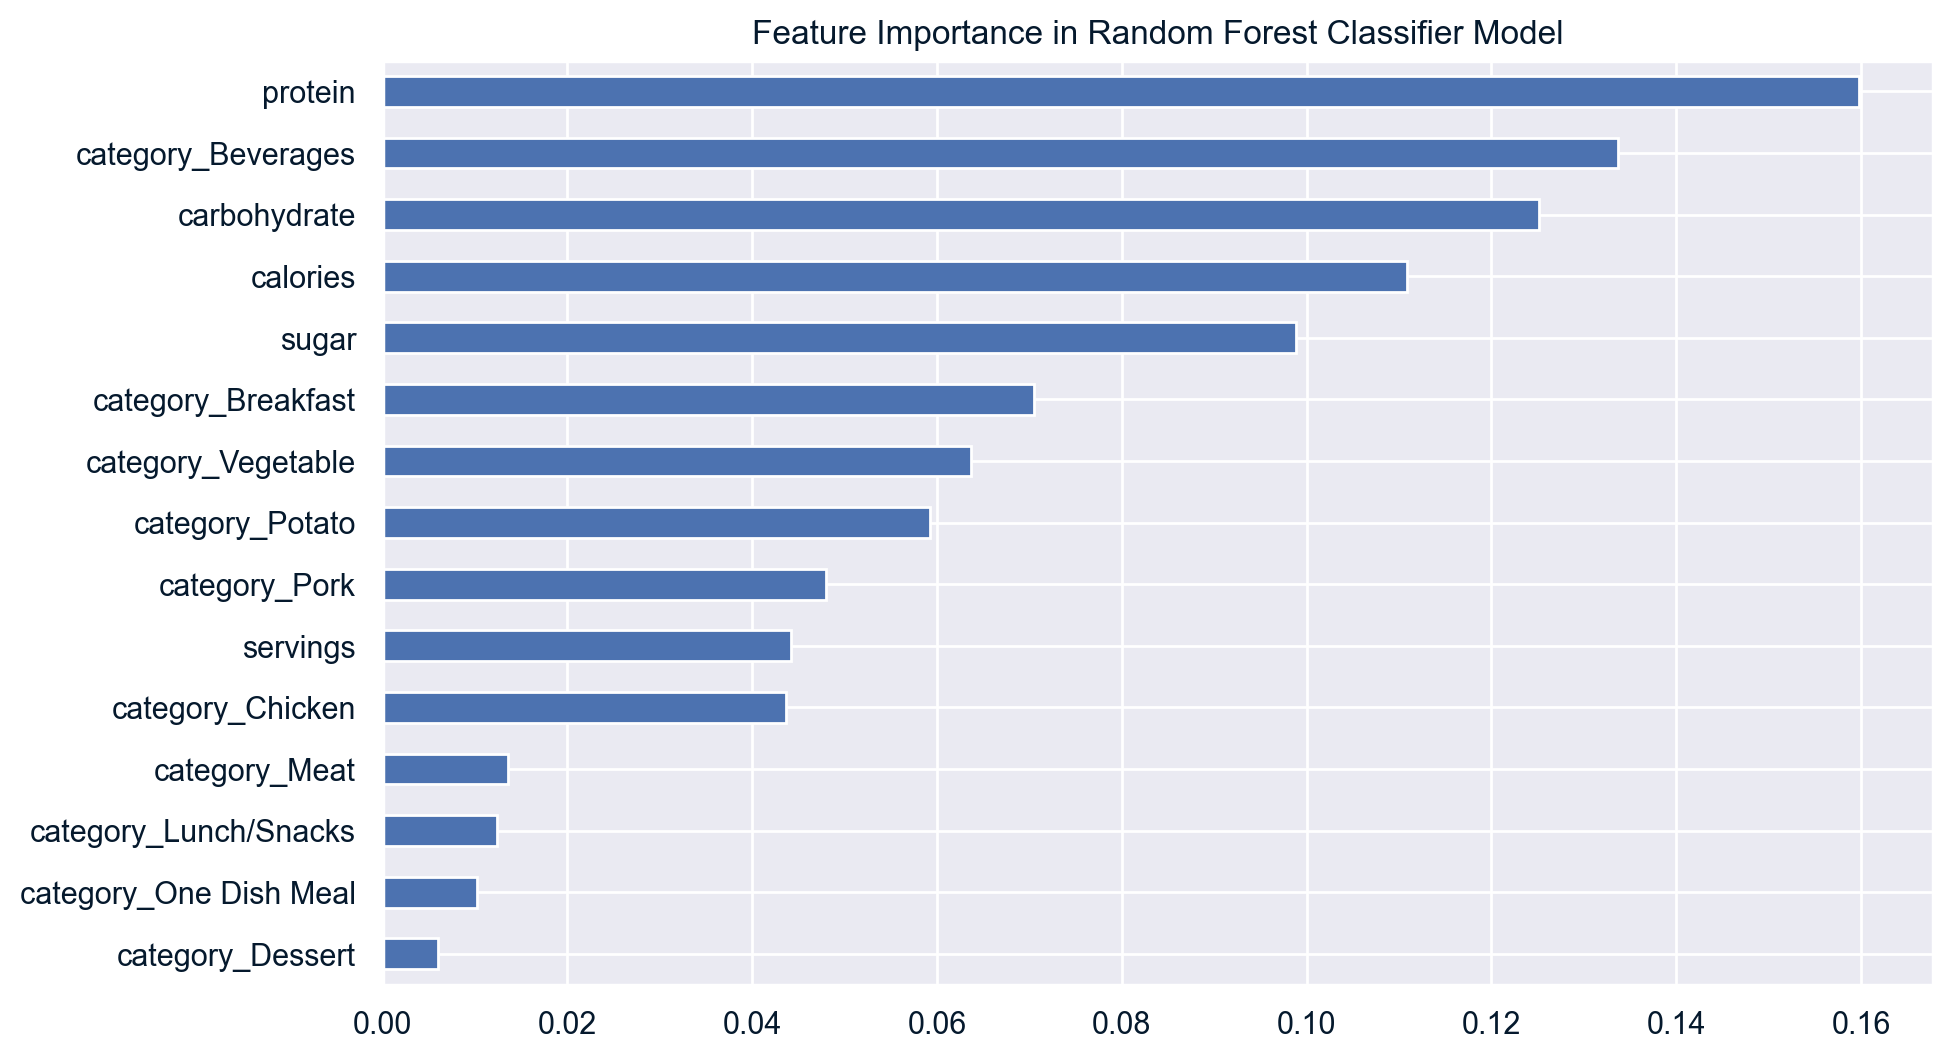

In [ ]:
importances_rf = pd.Series(rf.feature_importances_,index=column_order).sort_values()
plt.figure(figsize=(10, 6))
importances_rf.plot(kind='barh')
plt.title('Feature Importance in Random Forest Classifier Model')
plt.show()

The Random Forest Classifer Model has managed to meet the minimum requirement of predicting the 80% of the total of the high-traffic recipes (positive class). When it comes to the positive class instances, this model has obtained a recall of 0.80, a precision of 0.81 and a F1-score of 0.81, respectivelly. This means that the model has been able to predict correctly 80% of the total of truly high-traffic recipes (recall), and, besides that, among all the recipes predicted as high_traffic by the model, it correctly predicts 81% of hight-traffic recipes (precision). This model is then appropiate to be deployed in production as it has achieved to meet the minimum requirements of the company.

It's important to note as well, that the most predictive features in this model were the protein numeric variable, the dummy variable corresponding to the Beverages recipes category, and the rest of the numeric variables related to the nutritional information of the recipes (carbohydrate, calories and sugar).

**5. Business Focus & Business Metric**

As the business goals are predicting which recipes will be popular 80% of the time and minimize the chance of showing unpopular recipes (Low traffic) on the homepage, our Business KPI will be the % of recipes, predicted by the model as popular, which are truly popular (generate high web traffic), guaranteeing also that at least 80% of all the truly popular recipes are correctly detected. From a Machine Learning perspective, this KPI corresponds to the Positive class Precision, evaluated under the constraint of Recall ≥ 80%. Therefore, the model selected will be the one that:
- Meets the minimum Recall requirement (≥ 80%)
- Maximizes the Precision

This approach ensures the minimum traffic capture required by the business (80% of the total popular recipes), minimizes the exposure of non-popular recipes (Minimizes False Positives), and we therefore get a KPI that is actionable, comparable across models and aligned with business objectives.

In [ ]:
kpi_lr = (precision_lr*100) if recall_lr >= 0.80 else 0
kpi_rf = (precision_rf*100) if recall_rf >= 0.80 else 0
print(f"The Logistic Regression model achieved the minimum required results. KPI: {kpi_lr}%" if recall_lr >= 0.80 else "The Logistic Regression model couldn't achieve the minimum requirement of 80%")
print(f"The Random Forest Classifier model achieved the minimum required results. KPI: {kpi_rf:.2f}%" if recall_rf >= 0.80 else "The Random Forest Classifier model couldn't achieve the minimum requirement of 80%")

The Logistic Regression model couldn't achieve the minimum requirement of 80%
The Random Forest Classifier model achieved the minimum required results. KPI: 81.13%


As we can see, only the Random Forest Classifier model managed to meet the minimum requirements of the company of predicting at least 80% of the total truly high-traffic recipes. Besides that, it achieved to score a KPI of 81.13%, which means that, among all the recipes predicted as high_traffic by the model, it correctly predicts 81% of hight-traffic recipes.

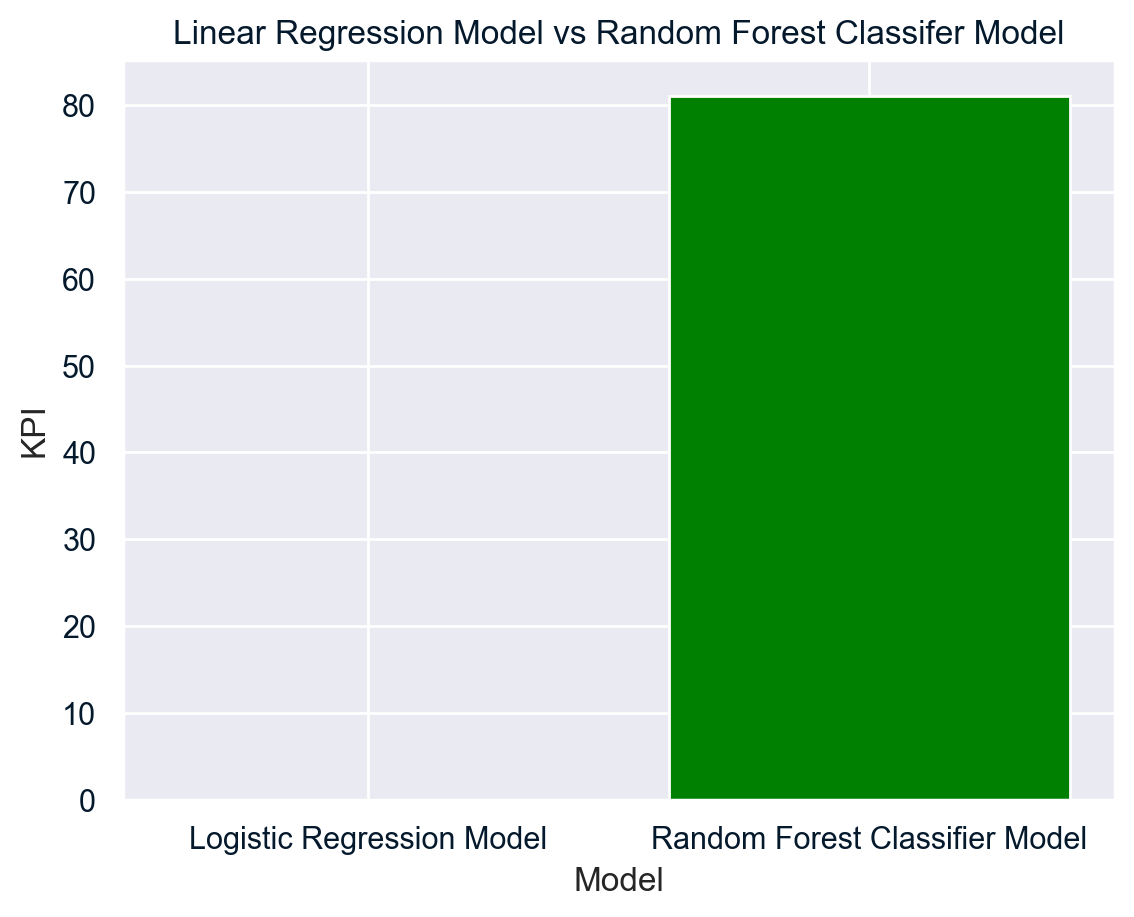

In [ ]:
kpis = [kpi_lr, kpi_rf]
labels = ['Logistic Regression Model', 'Random Forest Classifier Model']

plt.bar(labels, kpis, color='green')
plt.title('Linear Regression Model vs Random Forest Classifer Model')
plt.xlabel('Model')
plt.ylabel('KPI')
plt.show()

**6. Recommendations**

To help the Product Manager who is currently predicting the high traffic recipes, we recommend to deploy this Random Forest Classifier Model into production. By implementing this model, about **80%** of the prediction will make sure the traffic will be high. This will help Product Manager build their confidence in generating more traffic to the rest of the website.

We also give the following recommendations:
- Test the  model by comparing its predictions to the recipes manually selected by the Product Manager accounted for this task so far
- Identify and fix errors to improve model performance after testing
- Fully deploy the model into production using optimal deployment strategies in terms of performance and cost-effectiveness, such as a web, mobile app or API
- Regular Model Retraining: Retrain the model periodically. User preferences will change over time, so it is essential to keep the model up-to-date with the latest data to maintain its predictive performance
- Continuously improve the model by collecting more data, feature engineering, creating more meaningful features such as time to make or cost per serving
- Collect additional data for the minority class (low-traffic recipes) to avoid having a dataset with a class imbalance between low and high-traffic recipes